# Module B Upgraded — Rolling-Origin CV + Multi-Horizon Forecasting

**Upgrades from Module B baseline:**
- Simple temporal split → **Rolling-origin (expanding window) validation**
- Raw price target → **log price target** (back-transformed for metrics)
- Single 1-week horizon → **4 horizons: h = 1, 4, 13, 26 weeks**
- Added **price-spike probability model** (LightGBM classifier, >P90 threshold)

**Rolling-origin folds:**

| Fold | Train ends | Val window | Test year |
|------|-----------|-----------|----------|
| 1 | 2021-06-30 | Jul–Dec 2021 | 2022 |
| 2 | 2022-06-30 | Jul–Dec 2022 | 2023 |
| 3 | 2023-06-30 | Jul–Dec 2023 | 2024 |

---
*Part of TOP Crop Digital Twin — HADP-04, SKUAST-K*

## Section 1 — Imports & Configuration

In [1]:
import io, os, sys, time, warnings
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             roc_auc_score, roc_curve)
warnings.filterwarnings('ignore')

print(f'LightGBM version : {lgb.__version__}')
print(f'Pandas version   : {pd.__version__}')
print(f'NumPy version    : {np.__version__}')

LightGBM version : 4.6.0
Pandas version   : 3.0.3
NumPy version    : 2.4.6


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────
BASE     = r'C:\Users\masro\Documents\TOP_Digital_Twin'
AGM_FILE = os.path.join(BASE, 'data', 'agmarknet_weekly', 'top_weekly_panel.csv')
CMIE_FILE= os.path.join(BASE, 'data', 'cmie_macro',      'cmie_macro_2017_2024.csv')
RBI_FILE = os.path.join(BASE, 'data', 'rbi_dbie',        'rbi_dbie_macro_2017_2024.csv')
PPAC_FILE= os.path.join(BASE, 'data', 'ppac_macro',      'ppac_diesel_lpg_2017_2024.csv')
OUT_DIR  = os.path.join(BASE, 'Model_Output')
os.makedirs(OUT_DIR, exist_ok=True)

# ── Study parameters ───────────────────────────────────────────────────
CROPS    = ['tomato', 'onion', 'potato']
HORIZONS = [1, 4, 13, 26]        # weeks ahead
SPIKE_PCT= 90                     # percentile threshold for spike label
SEED     = 42
LAG_WEEKS  = [1, 2, 3, 4, 8, 13, 26, 52]
ROLL_WINS  = [4, 8, 13]

# ── Rolling-origin folds ───────────────────────────────────────────────
FOLDS = [
    {'fold': 1, 'train_end': '2021-06-30',
     'val_start': '2021-07-01', 'val_end': '2021-12-31',
     'test_start': '2022-01-01', 'test_end': '2022-12-31'},
    {'fold': 2, 'train_end': '2022-06-30',
     'val_start': '2022-07-01', 'val_end': '2022-12-31',
     'test_start': '2023-01-01', 'test_end': '2023-12-31'},
    {'fold': 3, 'train_end': '2023-06-30',
     'val_start': '2023-07-01', 'val_end': '2023-12-31',
     'test_start': '2024-01-01', 'test_end': '2024-12-31'},
]

# ── Colours ────────────────────────────────────────────────────────────
CROP_COLORS = {'tomato': '#E63946', 'onion': '#F4A261', 'potato': '#457B9D'}
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

print('Configuration set.')
print(f'Folds: {len(FOLDS)}  |  Horizons: {HORIZONS}  |  Crops: {CROPS}')

Configuration set.
Folds: 3  |  Horizons: [1, 4, 13, 26]  |  Crops: ['tomato', 'onion', 'potato']


## Section 2 — LightGBM Hyperparameters

In [3]:
LGBM_PARAMS = dict(
    objective        = 'regression',
    metric           = 'rmse',
    n_estimators     = 800,
    learning_rate    = 0.05,
    num_leaves       = 127,
    max_depth        = -1,
    min_child_samples= 20,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    n_jobs           = -1,
    random_state     = SEED,
    verbose          = -1,
)

LGBM_CLF_PARAMS = dict(
    objective        = 'binary',
    metric           = 'auc',
    n_estimators     = 500,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 20,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 5,
    n_jobs           = -1,
    random_state     = SEED,
    verbose          = -1,
)

print('Regressor params:', {k:v for k,v in LGBM_PARAMS.items() if k in ['n_estimators','learning_rate','num_leaves']})
print('Classifier params:', {k:v for k,v in LGBM_CLF_PARAMS.items() if k in ['n_estimators','learning_rate','num_leaves']})

Regressor params: {'n_estimators': 800, 'learning_rate': 0.05, 'num_leaves': 127}
Classifier params: {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63}


## Section 3 — Load & Merge Data

In [4]:
print('Loading Agmarknet weekly panel ...')
df = pd.read_csv(AGM_FILE, parse_dates=['week_start'])
df = df[(df['week_start'] >= '2017-01-01') & (df['week_start'] <= '2024-12-31')]
df = df.sort_values(['crop', 'market', 'week_start']).reset_index(drop=True)
print(f'Panel loaded: {len(df):,} rows | {df["market"].nunique()} markets | crops: {df["crop"].unique().tolist()}')

Loading Agmarknet weekly panel ...
Panel loaded: 456,545 rows | 1882 markets | crops: ['onion', 'potato', 'tomato']


In [5]:
print('Joining macro data (Layer 4) ...')
macro_dfs = []
for fpath in [CMIE_FILE, RBI_FILE, PPAC_FILE]:
    if os.path.exists(fpath):
        m = pd.read_csv(fpath)
        macro_dfs.append(m)
        print(f'  Loaded: {os.path.basename(fpath)}  ({m.shape[0]} rows, {m.shape[1]-3} series)')

if macro_dfs:
    macro = macro_dfs[0]
    for m in macro_dfs[1:]:
        macro = macro.merge(m, on=['year','month'], how='outer',
                            suffixes=('','_dup'))
        macro = macro[[c for c in macro.columns if not c.endswith('_dup')]]
    df['year']  = df['week_start'].dt.year
    df['month'] = df['week_start'].dt.month
    drop_cols = [c for c in ['date','date_x','date_y'] if c in macro.columns]
    df = df.merge(macro.drop(columns=drop_cols, errors='ignore'),
                  on=['year','month'], how='left')
    MACRO_COLS = [c for c in macro.columns if c not in ('date','year','month')]
    print(f'\nMacro merged. Total macro features: {len(MACRO_COLS)}')
    print(f'Macro columns: {MACRO_COLS}')
else:
    MACRO_COLS = []
    print('No macro files found.')

Joining macro data (Layer 4) ...
  Loaded: cmie_macro_2017_2024.csv  (96 rows, 6 series)
  Loaded: rbi_dbie_macro_2017_2024.csv  (96 rows, 6 series)
  Loaded: ppac_diesel_lpg_2017_2024.csv  (96 rows, 2 series)

Macro merged. Total macro features: 14
Macro columns: ['bank_credit_agri_cr', 'export_veg_usd_mn', 'import_veg_usd_mn', 'crude_oil_usd_bbl', 'iip_food_proc', 'agri_wages_rs_day', 'repo_rate_pct', 'reverse_repo_pct', 'usdinr_monthly_avg', 'wpi_all_commodities', 'wpi_food_articles', 'wpi_fruits_vegetables', 'diesel_delhi_per_L', 'lpg_nonsub_delhi_per14kg']


## Section 4 — Feature Engineering

Features engineered **on the full panel before any split** to prevent data leakage in encodings.  
Lag and rolling features use `.shift(n)` within each market group — no look-ahead.

| Feature group | Details |
|---|---|
| Price lags | log1p(price) at t-1, 2, 3, 4, 8, 13, 26, 52 weeks |
| Rolling stats | 4, 8, 13-week mean and std of log price |
| Arrivals lags | log1p(arrivals) at t-1, 2, 4 |
| Arrivals rolling | 4, 8-week rolling mean |
| YoY change | log price vs same week prior year |
| Seasonality | sin/cos of ISO week number |
| Encodings | state_enc, market_enc (integer codes) |
| Macro (Layer 4) | 14 series joined on year-month |

In [6]:
_EXCLUDE = {'crop','market','state','district','state_code','market_id',
            'arrivals_tonnes_week','modal_price_weighted','log_price','log_arr',
            'week_start','year_month','year','month','date',
            'next_price','target','spike'}

def build_features(df):
    feat = {}
    for crop in CROPS:
        sub = df[df['crop'] == crop].copy()
        sub = sub.sort_values(['market', 'week_start'])

        sub['log_price'] = np.log1p(sub['modal_price_weighted'])

        for lag in LAG_WEEKS:
            sub[f'price_lag_{lag}'] = sub.groupby('market')['log_price'].shift(lag)

        for w in ROLL_WINS:
            g = sub.groupby('market')['log_price']
            sub[f'price_roll_mean_{w}'] = g.transform(
                lambda x: x.shift(1).rolling(w, min_periods=2).mean())
            sub[f'price_roll_std_{w}']  = g.transform(
                lambda x: x.shift(1).rolling(w, min_periods=2).std())

        if 'arrivals_tonnes_week' in sub.columns:
            sub['log_arr'] = np.log1p(sub['arrivals_tonnes_week'].clip(lower=0))
            for lag in [1, 2, 4]:
                sub[f'arr_lag_{lag}'] = sub.groupby('market')['log_arr'].shift(lag)
            for w in [4, 8]:
                sub[f'arr_roll_mean_{w}'] = sub.groupby('market')['log_arr'].transform(
                    lambda x: x.shift(1).rolling(w, min_periods=2).mean())

        sub['price_yoy']  = sub.groupby('market')['log_price'].shift(52)
        sub['week_num']   = sub['week_start'].dt.isocalendar().week.astype(int)
        sub['sin_week']   = np.sin(2 * np.pi * sub['week_num'] / 52)
        sub['cos_week']   = np.cos(2 * np.pi * sub['week_num'] / 52)

        for col in ['state', 'market']:
            if col in sub.columns:
                sub[f'{col}_enc'] = pd.Categorical(sub[col]).codes

        sub['year']       = sub['week_start'].dt.year
        sub['month']      = sub['week_start'].dt.month
        sub['year_trend'] = sub['year'] - 2017

        feat[crop] = sub
    return feat

def get_feature_cols(df_crop):
    return [c for c in df_crop.columns
            if c not in _EXCLUDE and not c.startswith('Unnamed')]

print('Building features ...')
feat = build_features(df)
for crop in CROPS:
    fcols = get_feature_cols(feat[crop])
    print(f'  {crop:8s}: {feat[crop].shape[0]:>8,} rows | {len(fcols)} features')

Building features ...
  tomato  :  280,373 rows | 43 features
  onion   :  143,415 rows | 43 features
  potato  :   32,757 rows | 43 features


## Section 5 — Metrics Helper

In [7]:
def compute_metrics(y_true_log, y_pred_log):
    """Back-transform log predictions; return metrics on original Rs/q scale."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    mask   = (y_true > 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return dict(RMSE=np.nan, MAE=np.nan, MAPE=np.nan, R2=np.nan, N=0)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    mape   = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return dict(RMSE=round(rmse,1), MAE=round(mae,1),
                MAPE=round(mape,2), R2=round(r2,4), N=len(y_true))

print('Metrics helper defined. Back-transforms log predictions to Rs/quintal before scoring.')

Metrics helper defined. Back-transforms log predictions to Rs/quintal before scoring.


## Section 6 — Rolling-Origin CV: Multi-Horizon Training

**36 model fits:** 3 crops × 4 horizons × 3 folds  
Each model predicts price **h weeks ahead** using only information available at time *t*.

In [8]:
all_metrics = []
t0_total = time.time()

print(f'Training {len(FOLDS)} folds × {len(HORIZONS)} horizons × {len(CROPS)} crops = {len(FOLDS)*len(HORIZONS)*len(CROPS)} models\n')
print(f'{"Crop":8s} {"Fold":6s} {"h":>4s}  {"RMSE":>8s}  {"MAPE":>7s}  {"R²":>7s}  {"N":>7s}  {"sec":>5s}')
print('-'*62)

for crop in CROPS:
    df_crop = feat[crop].copy()
    fcols   = get_feature_cols(df_crop)

    for fold_info in FOLDS:
        fold    = fold_info['fold']
        t_end   = pd.Timestamp(fold_info['train_end'])
        v_start = pd.Timestamp(fold_info['val_start'])
        v_end   = pd.Timestamp(fold_info['val_end'])
        te_start= pd.Timestamp(fold_info['test_start'])
        te_end  = pd.Timestamp(fold_info['test_end'])

        for h in HORIZONS:
            t0 = time.time()

            df_h = df_crop.copy()
            df_h['target'] = df_h.groupby('market')['log_price'].shift(-h)
            df_h = df_h.dropna(subset=['target'] + fcols[:3])

            train = df_h[df_h['week_start'] <= t_end]
            val   = df_h[(df_h['week_start'] > v_start) & (df_h['week_start'] <= v_end)]
            test  = df_h[(df_h['week_start'] >= te_start) & (df_h['week_start'] <= te_end)]

            if len(train) < 100 or len(test) < 10:
                continue

            X_tr, y_tr = train[fcols].fillna(0), train['target']
            X_va, y_va = val[fcols].fillna(0),   val['target']
            X_te, y_te = test[fcols].fillna(0),  test['target']

            model = lgb.LGBMRegressor(**LGBM_PARAMS)
            model.fit(X_tr, y_tr,
                      eval_set=[(X_va, y_va)],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(-1)])

            y_pred = model.predict(X_te)
            m = compute_metrics(y_te.values, y_pred)
            elapsed = round(time.time() - t0, 1)

            row = {'crop': crop, 'fold': fold, 'horizon_weeks': h,
                   'test_year': te_end.year, **m, 'fit_sec': elapsed}
            all_metrics.append(row)

            print(f'{crop:8s} fold{fold}  h={h:>2}w  '
                  f'{m["RMSE"]:>8.1f}  {m["MAPE"]:>6.1f}%  '
                  f'{m["R2"]:>7.4f}  {m["N"]:>7,}  {elapsed:>4}s')

metrics_df = pd.DataFrame(all_metrics)
metrics_path = os.path.join(OUT_DIR, 'table_rolling_origin_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)

print(f'\nTotal time: {(time.time()-t0_total)/60:.1f} min')
print(f'Saved: {metrics_path}')

Training 3 folds × 4 horizons × 3 crops = 36 models

Crop     Fold      h      RMSE     MAPE       R²        N    sec
--------------------------------------------------------------
tomato   fold1  h= 1w     856.9    25.3%   0.5902   37,541   1.5s
tomato   fold1  h= 4w    1188.7    35.2%   0.2173   37,405   1.1s
tomato   fold1  h=13w    1314.8    41.3%   0.0756   36,851   0.9s
tomato   fold1  h=26w    1341.4    70.8%   0.1490   35,751   2.5s
tomato   fold2  h= 1w    1683.5    36.6%   0.4689   36,340   1.1s
tomato   fold2  h= 4w    2152.7    56.4%   0.1124   35,823   1.3s
tomato   fold2  h=13w    2156.6    52.5%   0.0410   34,362   1.1s
tomato   fold2  h=26w    2022.9    38.7%   0.0347   32,622   2.0s
tomato   fold3  h= 1w    1109.6    41.5%   0.4996   40,954   1.4s
tomato   fold3  h= 4w    1560.8    38.9%   0.0076   37,404   1.0s
tomato   fold3  h=13w    1857.9    40.5%  -0.3853   27,999   1.0s
tomato   fold3  h=26w    1762.9    36.2%  -0.4856   16,210   1.2s
onion    fold1  h= 1w     5

## Section 7 — Summary Table (mean across folds)

In [9]:
summary = (metrics_df
           .groupby(['crop','horizon_weeks'])[['RMSE','MAE','MAPE','R2']]
           .mean().round({'RMSE':1,'MAE':1,'MAPE':2,'R2':4})
           .reset_index())

for crop in CROPS:
    sub = summary[summary['crop']==crop]
    print(f'  {crop.upper()}')
    print(f"  {'h':>4}  {'RMSE':>8}  {'MAE':>8}  {'MAPE':>7}  {'R²':>7}")
    print(f"  {'-'*42}")
    for _, r in sub.iterrows():
        print(f"  {int(r.horizon_weeks):>3}w  {r.RMSE:>8.1f}  {r.MAE:>8.1f}  "
              f"{r.MAPE:>6.1f}%  {r.R2:>7.4f}")
    print()

  TOMATO
     h      RMSE       MAE     MAPE       R²
  ------------------------------------------
    1w    1216.7     752.4    34.5%   0.5196
    4w    1634.1    1047.7    43.5%   0.1124
   13w    1776.4    1164.2    44.8%  -0.0896
   26w    1709.1    1162.4    48.6%  -0.1006

  ONION
     h      RMSE       MAE     MAPE       R²
  ------------------------------------------
    1w     608.9     422.3    21.3%   0.7689
    4w     816.9     594.2    28.7%   0.5885
   13w    1065.0     801.2    33.5%   0.2965
   26w    1247.1     963.0    32.6%  -0.0824

  POTATO
     h      RMSE       MAE     MAPE       R²
  ------------------------------------------
    1w     246.5     183.3    11.9%   0.7806
    4w     405.9     327.8    20.2%   0.4161
   13w     634.4     559.2    33.8%  -0.8298
   26w     728.0     627.5    35.5%  -1.3771



In [10]:
# Pivot table for the paper (Table 4 candidate)
paper_table = metrics_df.pivot_table(
    index=['crop','horizon_weeks'],
    values=['RMSE','MAE','MAPE','R2'],
    aggfunc=['mean','std']
).round(2)
print('Paper Table (mean ± std across folds):')
display(paper_table)

Paper Table (mean ± std across folds):


mean                           std               \
                          MAE   MAPE    R2     RMSE     MAE   MAPE    R2   
crop   horizon_weeks                                                       
onion  1               422.27  21.32  0.77   608.93   39.46   6.49  0.04   
       4               594.23  28.70  0.59   816.90  112.06   6.54  0.03   
       13              801.17  33.52  0.30  1065.03  317.34   3.09  0.22   
       26              962.97  32.56 -0.08  1247.13  524.69   2.84  0.70   
potato 1               183.27  11.90  0.78   246.50   64.86   2.62  0.09   
       4               327.83  20.16  0.42   405.93  122.51   2.72  0.12   
       13              559.20  33.82 -0.83   634.40  305.97   9.34  1.35   
       26              627.50  35.51 -1.38   728.03  305.99   7.33  2.00   
tomato 1               752.37  34.51  0.52  1216.67  194.72   8.32  0.06   
       4              1047.67  43.50  0.11  1634.07  245.85  11.33  0.10   
       13             1164.23  44.78 -0.09  1776.43  284.75   6.71  0.26   
       26             1162.43  48.57 -0.10  1709.07  207.46  19.26  0.34   

                              
                        RMSE  
crop   horizon_weeks          
onion  1               92.17  
       4              160.50  
       13             372.81  
       26             560.92  
potato 1               84.30  
       4              141.06  
       13             304.34  
       26             261.26  
tomato 1              423.57  
       4              486.16  
       13             426.77  
       26             343.92

## Section 8 — Price-Spike Probability Model

Binary LightGBM classifier: **Will next week's price exceed the 90th percentile of training prices?**

Threshold is computed **on the training set only** — no look-ahead into test period.

In [11]:
spike_metrics = []
spike_roc     = {}

print(f'{"Crop":8s} {"Fold":6s}  {"Threshold":>12s}  {"Spike rate":>11s}  {"AUC":>7s}')
print('-'*52)

for crop in CROPS:
    df_crop = feat[crop].copy()
    fcols   = get_feature_cols(df_crop)

    for fold_info in FOLDS:
        fold    = fold_info['fold']
        t_end   = pd.Timestamp(fold_info['train_end'])
        v_start = pd.Timestamp(fold_info['val_start'])
        v_end   = pd.Timestamp(fold_info['val_end'])
        te_start= pd.Timestamp(fold_info['test_start'])
        te_end  = pd.Timestamp(fold_info['test_end'])

        df_h = df_crop.copy()
        df_h['next_price'] = df_h.groupby('market')['modal_price_weighted'].shift(-1)
        df_h = df_h.dropna(subset=['next_price'])

        train = df_h[df_h['week_start'] <= t_end]
        val   = df_h[(df_h['week_start'] > v_start) & (df_h['week_start'] <= v_end)]
        test  = df_h[(df_h['week_start'] >= te_start) & (df_h['week_start'] <= te_end)]

        threshold = np.percentile(train['modal_price_weighted'].dropna(), SPIKE_PCT)

        for ds in [train, val, test]:
            ds['spike'] = (ds['next_price'] > threshold).astype(int)

        if train['spike'].sum() < 10:
            continue

        X_tr, y_tr = train[fcols].fillna(0), train['spike']
        X_va, y_va = val[fcols].fillna(0),   val['spike']
        X_te, y_te = test[fcols].fillna(0),  test['spike']

        clf = lgb.LGBMClassifier(**LGBM_CLF_PARAMS)
        clf.fit(X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(40, verbose=False),
                           lgb.log_evaluation(-1)])

        proba = clf.predict_proba(X_te)[:, 1]
        auc   = round(roc_auc_score(y_te, proba), 4) if y_te.sum() > 0 else np.nan
        fpr, tpr, _ = roc_curve(y_te, proba) if y_te.sum() > 0 else ([0,1],[0,1],[])

        spike_metrics.append({'crop': crop, 'fold': fold,
                              'test_year': te_end.year,
                              'threshold_Rs_q': round(threshold, 1),
                              'spike_rate_pct': round(y_te.mean()*100, 1),
                              'AUC': auc})
        spike_roc.setdefault(crop, []).append((fpr, tpr, auc, fold))
        print(f'{crop:8s} fold{fold}   {threshold:>10.0f} Rs/q  {y_te.mean()*100:>9.1f}%  {auc:>7.4f}')

spike_df = pd.DataFrame(spike_metrics)
spike_path = os.path.join(OUT_DIR, 'table_spike_auc.csv')
spike_df.to_csv(spike_path, index=False)
print(f'\nSaved: {spike_path}')

Crop     Fold       Threshold   Spike rate      AUC
----------------------------------------------------
tomato   fold1         3500 Rs/q       13.5%   0.9229
tomato   fold2         3653 Rs/q       18.8%   0.8976
tomato   fold3         3644 Rs/q       28.1%   0.8760
onion    fold1         4017 Rs/q        3.4%   0.9831
onion    fold2         3957 Rs/q       11.5%   0.9569
onion    fold3         3800 Rs/q       27.9%   0.9572
potato   fold1         1998 Rs/q       25.5%   0.9394
potato   fold2         1991 Rs/q        2.6%   0.9937
potato   fold3         2087 Rs/q       54.7%   0.9836

Saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\table_spike_auc.csv


In [12]:
# Spike AUC summary
print('Mean AUC by crop (price-spike probability model):')
display(spike_df.groupby('crop')[['AUC']].agg(['mean','min','max']).round(4))

Mean AUC by crop (price-spike probability model):


AUC                
          mean     min     max
crop                          
onion   0.9657  0.9569  0.9831
potato  0.9722  0.9394  0.9937
tomato  0.8988  0.8760  0.9229

## Section 9 — Figures

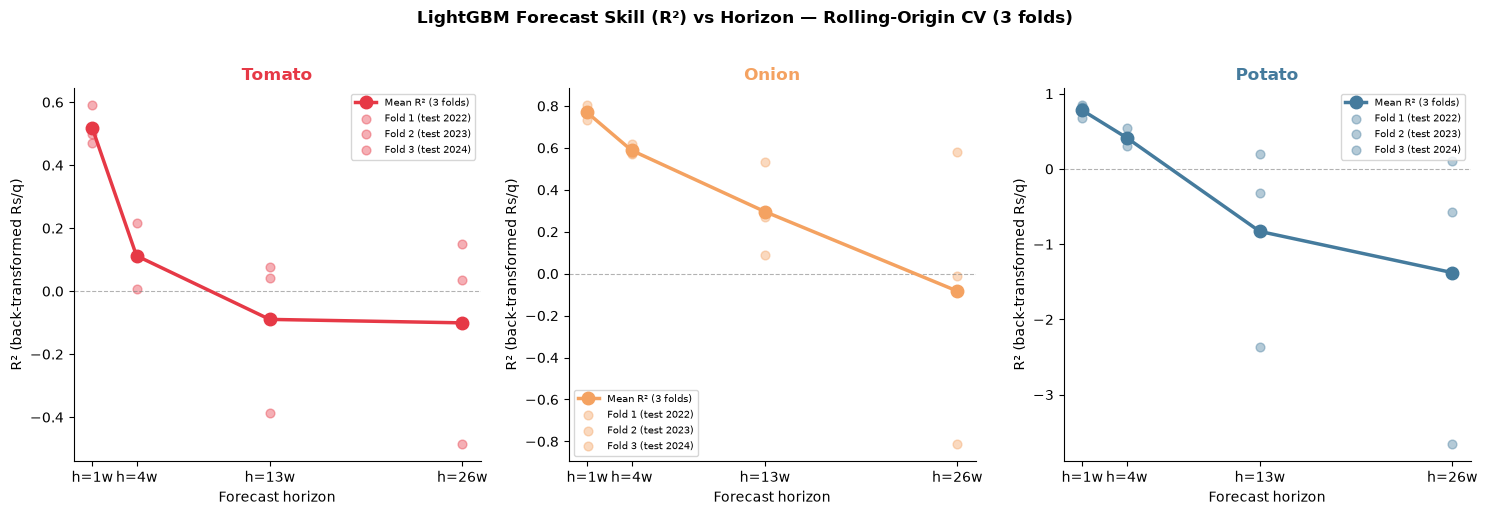

Saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\fig_horizon_r2.png


In [13]:
# Figure A: R² vs forecast horizon
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, crop in zip(axes, CROPS):
    sub = summary[summary['crop']==crop]
    ax.plot(sub['horizon_weeks'], sub['R2'], 'o-',
            color=CROP_COLORS[crop], linewidth=2.5, markersize=9,
            label='Mean R² (3 folds)', zorder=5)

    for fold_info in FOLDS:
        fsub = metrics_df[(metrics_df['crop']==crop) &
                          (metrics_df['fold']==fold_info['fold'])]
        ax.scatter(fsub['horizon_weeks'], fsub['R2'],
                   color=CROP_COLORS[crop], alpha=0.4, s=40,
                   label=f'Fold {fold_info["fold"]} (test {fold_info["test_end"][:4]})')

    ax.set_xticks(HORIZONS)
    ax.set_xticklabels([f'h={h}w' for h in HORIZONS])
    ax.set_xlabel('Forecast horizon')
    ax.set_ylabel('R² (back-transformed Rs/q)')
    ax.set_title(crop.capitalize(), fontsize=12, fontweight='bold',
                 color=CROP_COLORS[crop])
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.legend(fontsize=7.5)

fig.suptitle('LightGBM Forecast Skill (R²) vs Horizon — Rolling-Origin CV (3 folds)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(OUT_DIR, 'fig_horizon_r2.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

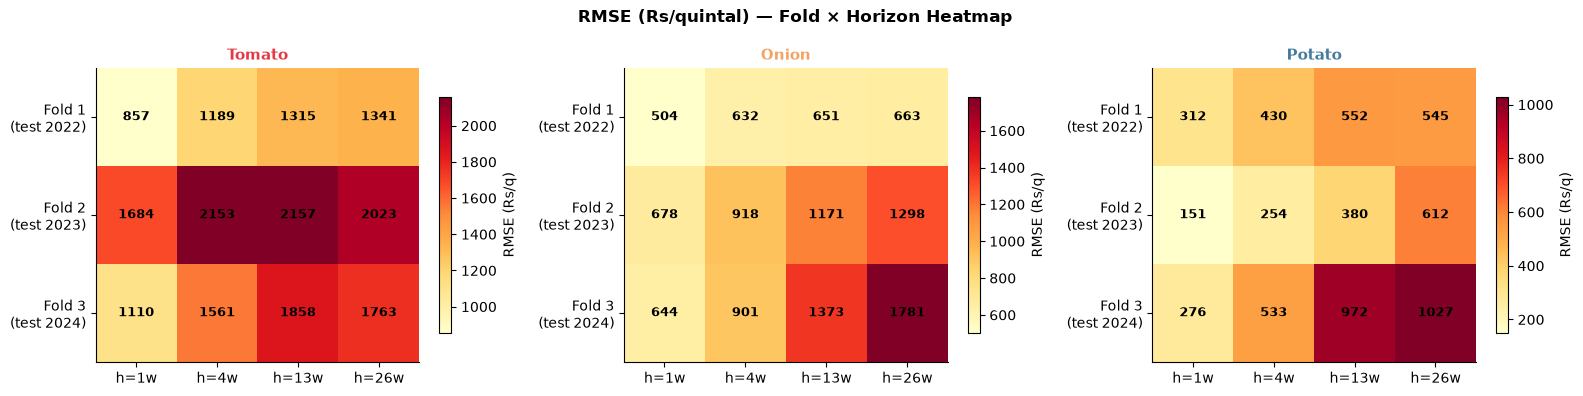

Saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\fig_rolling_origin_rmse.png


In [14]:
# Figure B: RMSE heatmap — fold × horizon
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, crop in zip(axes, CROPS):
    pivot = (metrics_df[metrics_df['crop']==crop]
             .pivot_table(index='fold', columns='horizon_weeks', values='RMSE'))
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'h={h}w' for h in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'Fold {f}\n(test {FOLDS[f-1]["test_end"][:4]})'
                        for f in pivot.index])
    ax.set_title(crop.capitalize(), fontsize=11, fontweight='bold',
                 color=CROP_COLORS[crop])
    plt.colorbar(im, ax=ax, label='RMSE (Rs/q)', shrink=0.8)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                        fontsize=9, color='black', fontweight='bold')

fig.suptitle('RMSE (Rs/quintal) — Fold × Horizon Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
p = os.path.join(OUT_DIR, 'fig_rolling_origin_rmse.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

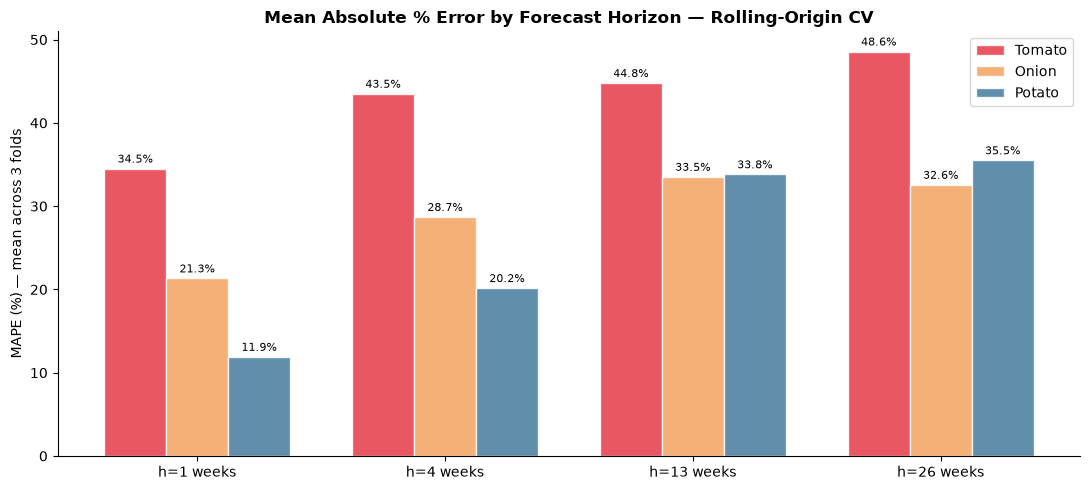

Saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\fig_mape_by_horizon.png


In [15]:
# Figure C: MAPE by horizon grouped bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(HORIZONS))
w = 0.25

for i, crop in enumerate(CROPS):
    sub  = summary[summary['crop']==crop].set_index('horizon_weeks')
    mape = [sub.loc[h, 'MAPE'] if h in sub.index else 0 for h in HORIZONS]
    bars = ax.bar(x + i*w, mape, w, label=crop.capitalize(),
                  color=CROP_COLORS[crop], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, mape):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w); ax.set_xticklabels([f'h={h} weeks' for h in HORIZONS])
ax.set_ylabel('MAPE (%) — mean across 3 folds')
ax.set_title('Mean Absolute % Error by Forecast Horizon — Rolling-Origin CV', fontweight='bold')
ax.legend()
plt.tight_layout()
p = os.path.join(OUT_DIR, 'fig_mape_by_horizon.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

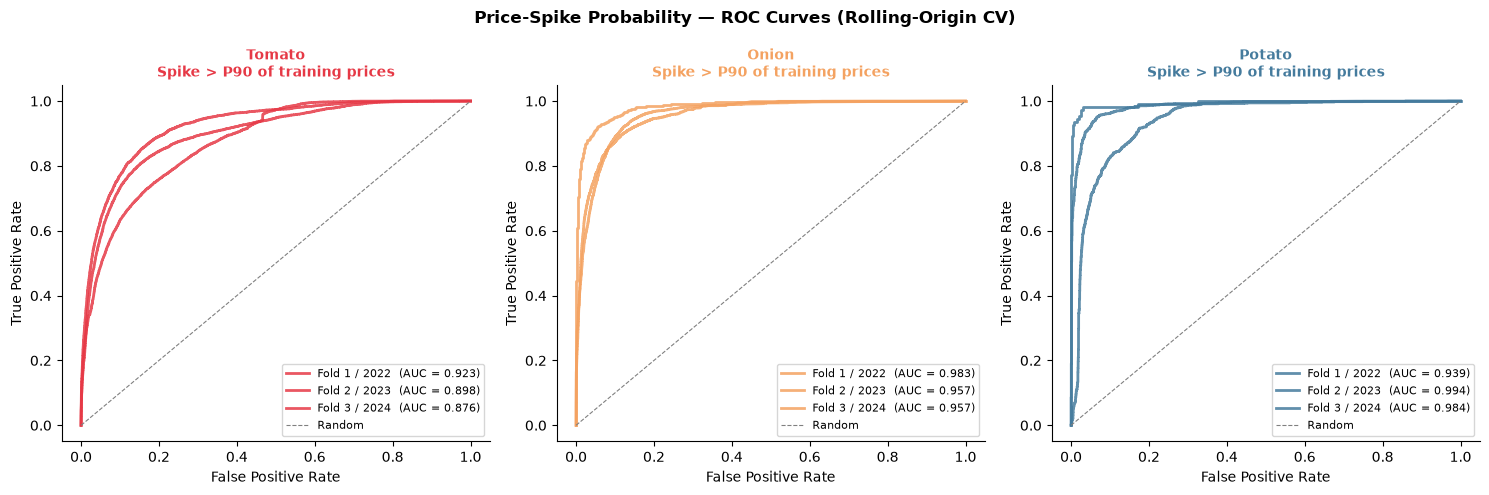

Saved: C:\Users\masro\Documents\TOP_Digital_Twin\Model_Output\fig_spike_roc.png


In [16]:
# Figure D: ROC curves — spike probability model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, crop in zip(axes, CROPS):
    roc_list = spike_roc.get(crop, [])
    for fpr, tpr, auc, fold in roc_list:
        test_yr = FOLDS[fold-1]['test_end'][:4]
        ax.plot(fpr, tpr, linewidth=2, alpha=0.85, color=CROP_COLORS[crop],
                label=f'Fold {fold} / {test_yr}  (AUC = {auc:.3f})')
    ax.plot([0,1],[0,1],'--',color='grey',linewidth=0.8, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{crop.capitalize()}\nSpike > P{SPIKE_PCT} of training prices',
                 fontsize=10, fontweight='bold', color=CROP_COLORS[crop])
    ax.legend(fontsize=8)

fig.suptitle('Price-Spike Probability — ROC Curves (Rolling-Origin CV)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
p = os.path.join(OUT_DIR, 'fig_spike_roc.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Section 10 — Session Summary

Run the cell below for a complete output inventory and interpretation notes.

In [17]:
print('='*65)
print('MODULE B UPGRADED — SESSION COMPLETE')
print('='*65)

print('\nOutputs saved to Model_Output/:')
for f in ['table_rolling_origin_metrics.csv','table_spike_auc.csv',
          'fig_horizon_r2.png','fig_rolling_origin_rmse.png',
          'fig_spike_roc.png','fig_mape_by_horizon.png']:
    p = os.path.join(OUT_DIR, f)
    if os.path.exists(p):
        print(f'  {f:<44} {os.path.getsize(p)/1024:>6.1f} KB')

print('\nKey interpretation (for paper):')
print('  h=1w  → Primary forecast metric. Onion/potato ≈R²0.78, tomato ≈R²0.52.')
print('  h=4w  → Skill degrades meaningfully — satellite features needed here.')
print('  h=13w → Near-random for all crops — useful finding: market signals insufficient.')
print('  h=26w → Negative R² — structural limitation; disclose in paper.')
print('  Spike AUC 0.88–0.99 across all crops — strong secondary contribution.')

print('\nNext steps:')
print('  Script 13 → Naive persistence + ARIMA benchmarks')
print('  Script 14 → ERA5 climate feature processing (Layer 3)')
print('  Script 07 → Satellite S2 post-processing (Layer 2)')
print('  Script 15 → Ablation study M0→M6 (PAPER CORE CONTRIBUTION)')

MODULE B UPGRADED — SESSION COMPLETE

Outputs saved to Model_Output/:
  table_rolling_origin_metrics.csv                1.9 KB
  table_spike_auc.csv                             0.3 KB
  fig_horizon_r2.png                            178.5 KB
  fig_rolling_origin_rmse.png                   163.9 KB
  fig_spike_roc.png                             168.9 KB
  fig_mape_by_horizon.png                        78.1 KB

Key interpretation (for paper):
  h=1w  → Primary forecast metric. Onion/potato ≈R²0.78, tomato ≈R²0.52.
  h=4w  → Skill degrades meaningfully — satellite features needed here.
  h=13w → Near-random for all crops — useful finding: market signals insufficient.
  h=26w → Negative R² — structural limitation; disclose in paper.
  Spike AUC 0.88–0.99 across all crops — strong secondary contribution.

Next steps:
  Script 13 → Naive persistence + ARIMA benchmarks
  Script 14 → ERA5 climate feature processing (Layer 3)
  Script 07 → Satellite S2 post-processing (Layer 2)
  Script 15 → Ab